In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content
# we only re-clone if the repo isn't already there
import os
if not os.path.exists('/content/cdt-alzheimer-screening'):
    !git clone https://github.com/wiambenadder/cdt-alzheimer-screening.git
%cd cdt-alzheimer-screening
!git pull   # we pick up any pushes since last session
!pip install -q -r requirements.txt

Mounted at /content/drive
/content
Cloning into 'cdt-alzheimer-screening'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 297 (delta 46), reused 6 (delta 6), pack-reused 204 (from 3)
Receiving objects: 100% (297/297), 2.34 MiB | 9.83 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/content/cdt-alzheimer-screening
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 146.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.2 MB/s eta 0:00:00


In [ ]:
import shutil, time
from pathlib import Path
import pandas as pd

# 1. we re-stage images from Drive to local SSD
LOCAL_DATA_DIR = Path('/content/nhats_local')
LOCAL_DATA_DIR.mkdir(exist_ok=True)
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/cdt-data/nhats_raw')

t0 = time.time()
for round_folder in sorted(DRIVE_DATA_DIR.iterdir()):
    if not round_folder.is_dir():
        continue
    dst = LOCAL_DATA_DIR / round_folder.name
    if dst.exists() and len(list(dst.glob('*.tif'))) > 0:
        print(f"[skip] {round_folder.name} already staged")
        continue
    print(f"[copy] {round_folder.name} -> local...")
    shutil.copytree(round_folder, dst, dirs_exist_ok=True)

n_staged = sum(1 for _ in LOCAL_DATA_DIR.rglob('*.tif'))
print(f"\n[done] {n_staged:,} TIFFs staged in {(time.time()-t0)/60:.1f} min")

# 2) we re-build the local labels CSV
drive_labels = pd.read_csv('/content/drive/MyDrive/cdt-data/labels.csv')
drive_labels['image_path'] = drive_labels['image_path'].str.replace(
    '/content/drive/MyDrive/cdt-data/nhats_raw/',
    '/content/nhats_local/',
    regex=False,
)
LOCAL_LABELS = Path('/content/cdt_labels_local.csv')
drive_labels.to_csv(LOCAL_LABELS, index=False)
print(f"\n[ok] Wrote {len(drive_labels):,} local-path labels -> {LOCAL_LABELS}")

[copy] round_01 -> local...
[copy] round_02 -> local...
[copy] round_03 -> local...
[copy] round_04 -> local...
[copy] round_05 -> local...
[copy] round_06 -> local...
[copy] round_07 -> local...
[copy] round_08 -> local...
[copy] round_09 -> local...
[copy] round_10 -> local...
[copy] round_11 -> local...
[copy] round_12 -> local...
[copy] round_13 -> local...
[copy] round_14 -> local...

[done] 73,769 TIFFs staged in 47.9 min

[ok] Wrote 59,417 local-path labels -> /content/cdt_labels_local.csv


In [ ]:
# this is an archive run AFTER staging works
import os
!tar -cf /content/drive/MyDrive/cdt-data/nhats_local.tar -C /content nhats_local
print(f"Archive size: {os.path.getsize('/content/drive/MyDrive/cdt-data/nhats_local.tar')/1e9:.1f} GB")

Archive size: 3.3 GB


In [ ]:
import sys
sys.path.insert(0, '/content/cdt-alzheimer-screening')

import src.config as cfg
from pathlib import Path

cfg.LABELS_CSV     = Path('/content/cdt_labels_local.csv')
cfg.MODELS_DIR     = Path('/content/drive/MyDrive/cdt-data/models')
cfg.RESULTS_DIR    = Path('/content/drive/MyDrive/cdt-data/results')
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

assert cfg.LABELS_CSV.exists(), "Run notebook 01 first to create local labels + staged images"
print(f"Labels: {cfg.LABELS_CSV}")
print(f"Local images staged: {sum(1 for _ in Path('/content/nhats_local').rglob('*.tif')):,}")

Labels: /content/cdt_labels_local.csv
Local images staged: 73,769


In [ ]:
import pandas as pd
from src.data import stratified_split, compute_class_weights, CDTDataset, build_dataloaders
from src.config import DataConfig
from src.augmentation import build_train_transform, build_eval_transform, AugConfig

df = pd.read_csv(cfg.LABELS_CSV)
df = df.rename(columns={'cdt_score': 'label'})[['participant_id', 'label', 'image_path']]
print(f"Loaded {len(df):,} samples")

data_cfg = DataConfig(batch_size=32, num_workers=2)
train_df, val_df, test_df = stratified_split(df, data_cfg)

class_weights = compute_class_weights(train_df)
print(f"Class weights: {class_weights.tolist()}")

Loaded 59,417 samples
[split] train=41591  val=8913  test=8913
Class weights: [18.386825561523438, 5.0634284019470215, 1.4994231462478638, 0.7781581878662109, 0.4506750702857971, 0.6340284943580627]


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

majority_class = int(train_df['label'].value_counts().idxmax())
print(f"Majority class in train set: {majority_class}")

y_test = test_df['label'].values
y_pred_majority = np.full_like(y_test, majority_class)

print("\n=== BASELINE 1: Majority-class predictor ===")
print(f"Accuracy:        {accuracy_score(y_test, y_pred_majority):.4f}")
print(f"Macro-F1:        {f1_score(y_test, y_pred_majority, average='macro', zero_division=0):.4f}")
print(f"Weighted-F1:     {f1_score(y_test, y_pred_majority, average='weighted', zero_division=0):.4f}")
print(f"Quadratic Kappa: {cohen_kappa_score(y_test, y_pred_majority, weights='quadratic'):.4f}")

# we save this to compare later
baseline_results = {
    'majority_class': {
        'accuracy': float(accuracy_score(y_test, y_pred_majority)),
        'macro_f1': float(f1_score(y_test, y_pred_majority, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_test, y_pred_majority, average='weighted', zero_division=0)),
        'quadratic_kappa': float(cohen_kappa_score(y_test, y_pred_majority, weights='quadratic')),
    }
}

Majority class in train set: 4

=== BASELINE 1: Majority-class predictor ===
Accuracy:        0.3698
Macro-F1:        0.0900
Weighted-F1:     0.1997
Quadratic Kappa: 0.0000


In [ ]:
import importlib, src.train, src.models
importlib.reload(src.train); importlib.reload(src.models)
from src.train import train
from src.config import TrainConfig, AugConfig

aug_cfg = AugConfig()
train_tf = build_train_transform(data_cfg.image_size, aug_cfg, use_aug=True)
eval_tf  = build_eval_transform(data_cfg.image_size)

train_ds = CDTDataset(train_df, transform=train_tf)
val_ds   = CDTDataset(val_df,   transform=eval_tf)
test_ds  = CDTDataset(test_df,  transform=eval_tf)

train_loader, val_loader, test_loader = build_dataloaders(
    train_ds, val_ds, test_ds, data_cfg,
)

# this is a short 5 epoch run to get the baseline quickly
train_cfg = TrainConfig(
    epochs=5,
    lr_head=1e-3,
    lr_backbone=0,       # frozen
    early_stopping_patience=3,
    mixed_precision=True,
)

summary = train(
    model_name='vgg16',
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    cfg=train_cfg,
    run_name='vgg16_frozen_baseline',
    freeze_backbone=True,
)
print(f"\nBest val loss: {summary['best_val_loss']:.4f}")
print(f"Checkpoint: {summary['checkpoint_path']}")

[train] run=vgg16_frozen_baseline device=cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 152MB/s]


[train] params total=134,285,126 trainable=119,570,438


/content/cdt-alzheimer-screening/src/train.py:155: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(cfg.mixed_precision and device == "cuda"))
epoch 0 [train]:   0%|          | 0/1299 [00:00<?, ?it/s]/content/cdt-alzheimer-screening/src/train.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.mixed_precision):
/content/cdt-alzheimer-screening/src/train.py:87: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[train] ep=00 tr_loss=2.3529 tr_acc=0.283 val_loss=1.8778 val_acc=0.279


[train] ep=01 tr_loss=2.0046 tr_acc=0.252 val_loss=2.1392 val_acc=0.379


[train] ep=02 tr_loss=1.9448 tr_acc=0.255 val_loss=1.7065 val_acc=0.242


[train] ep=03 tr_loss=1.8090 tr_acc=0.286 val_loss=1.4983 val_acc=0.443


[train] ep=04 tr_loss=1.6095 tr_acc=0.319 val_loss=1.4392 val_acc=0.452

Best val loss: 1.4392
Checkpoint: /content/drive/MyDrive/cdt-data/models/vgg16_frozen_baseline_best.pt


In [ ]:
import torch, json
from src.models import get_model
from src.evaluate import collect_predictions, compute_all_metrics
from src.utils import get_device, load_checkpoint

device = get_device()
model, _, _ = get_model('vgg16', freeze_backbone=True, dropout=0.3)
model = load_checkpoint(model, summary['checkpoint_path'], device=device).to(device)

y_true, y_pred, y_probs = collect_predictions(model, test_loader, device)
metrics = compute_all_metrics(y_true, y_pred, y_probs)
baseline_results['vgg16_frozen'] = metrics

print("\n=== BASELINE 2: VGG16 frozen feature extractor ===")
for k, v in metrics.items():
    print(f"  {k:20s} {v}")

# we save both baselines
out = cfg.RESULTS_DIR / 'baselines.json'
with open(out, 'w') as f:
    json.dump(baseline_results, f, indent=2)
print(f"\nSaved to {out}")


=== BASELINE 2: VGG16 frozen feature extractor ===
  accuracy             0.45416806911253227
  macro_f1             0.415561634141224
  weighted_f1          0.44867533753420613
  macro_precision      0.4218735312997777
  macro_recall         0.4250675950810081
  quadratic_kappa      0.6368116548100001
  macro_auc            0.8001114487206262

Saved to /content/drive/MyDrive/cdt-data/results/baselines.json


In [2]:
from pathlib import Path

# we search the entire cdt-data folder for any history.json files
search_root = Path('/content/drive/MyDrive/cdt-data')
found = list(search_root.rglob('history.json'))
print("Found history files:")
for f in found:
    print(f)

# we also check what is actually in the results directory
results = search_root / 'results'
print("\nContents of results/:")
for item in sorted(results.iterdir()):
    print(item)

Found history files:
/content/drive/MyDrive/cdt-data/results/vgg16_frozen_baseline/history.json

Contents of results/:
/content/drive/MyDrive/cdt-data/results/ablation_results.json
/content/drive/MyDrive/cdt-data/results/ablation_table.csv
/content/drive/MyDrive/cdt-data/results/all_results.csv
/content/drive/MyDrive/cdt-data/results/baselines.json
/content/drive/MyDrive/cdt-data/results/class_distribution.png
/content/drive/MyDrive/cdt-data/results/comparison.csv
/content/drive/MyDrive/cdt-data/results/errors
/content/drive/MyDrive/cdt-data/results/finetuning_results.json
/content/drive/MyDrive/cdt-data/results/sample_clocks_by_class.png
/content/drive/MyDrive/cdt-data/results/smartcrop_before_after.png
/content/drive/MyDrive/cdt-data/results/training_curves.png
/content/drive/MyDrive/cdt-data/results/vgg16_frozen_baseline
/content/drive/MyDrive/cdt-data/results/vit_attribution_maps.png
/content/drive/MyDrive/cdt-data/results/vit_classification_report.json
/content/drive/MyDrive/cdt-d

In [3]:
import json

with open('/content/drive/MyDrive/cdt-data/results/finetuning_results.json') as f:
    results = json.load(f)

for run_name, metrics in results.items():
    print(f"\n{run_name}:")
    for k, v in metrics.items():
        print(f"  {k}: {v}")


vgg16_ft:
  accuracy: 0.6160214813157305
  macro_f1: 0.5842349264284372
  weighted_f1: 0.611970449141383
  macro_precision: 0.5765624076261199
  macro_recall: 0.6042648981586608
  quadratic_kappa: 0.7813349786317518
  macro_auc: 0.9026010326427433
  run_name: vgg16_ft
  best_epoch: 6
  note: trained 8 epochs, stopped manually for time budget

effb0_ft:
  accuracy: 0.5895054822107854
  macro_f1: 0.5493392989983227
  weighted_f1: 0.586668877384202
  macro_precision: 0.5360601087117595
  macro_recall: 0.583421318895923
  quadratic_kappa: 0.7465471945279865
  macro_auc: 0.8932002441375296
  run_name: effb0_ft
  best_epoch: 7
  minutes: 150.4135691245397

vit_b16_ft:
  accuracy: 0.671850525844708
  macro_f1: 0.6483722009825265
  weighted_f1: 0.6714299063697348
  macro_precision: 0.6328339901983162
  macro_recall: 0.673890432218493
  quadratic_kappa: 0.808468356197879
  macro_auc: 0.9253265860583042
  run_name: vit_b16_ft
  best_epoch: 5
  minutes: 116.05480935176213


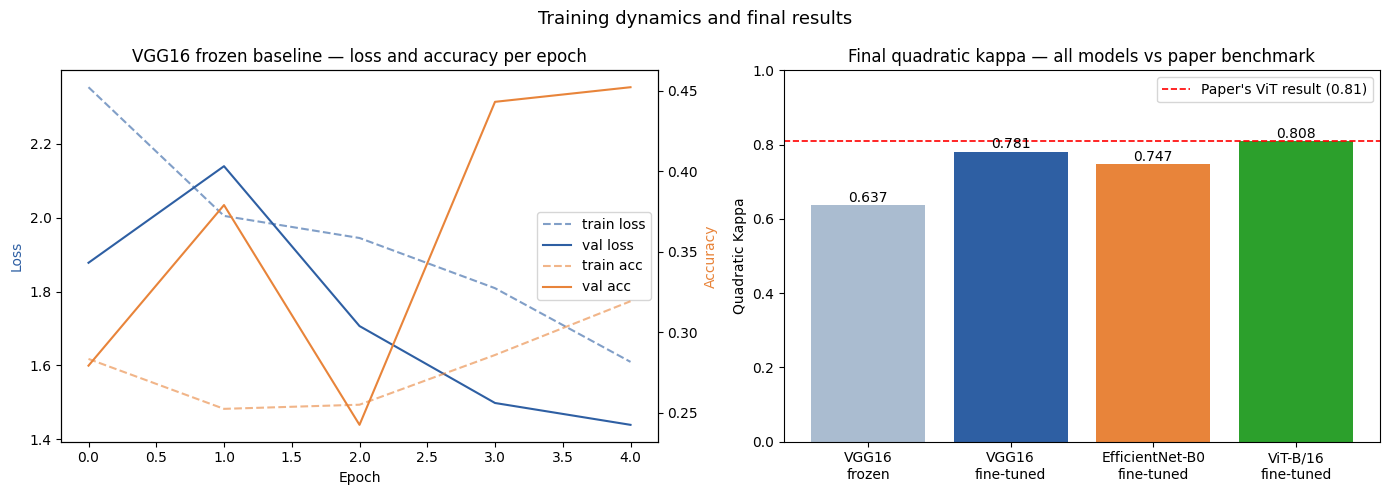

saved to Drive


In [4]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path('/content/drive/MyDrive/cdt-data/results')

# we load the one run that has epoch history
with open(RESULTS_DIR / 'vgg16_frozen_baseline' / 'history.json') as f:
    frozen_history = json.load(f)

# we load final metrics for all fine-tuned models
with open(RESULTS_DIR / 'finetuning_results.json') as f:
    ft_results = json.load(f)

# we load baselines so frozen VGG16 appears in the bar chart
with open(RESULTS_DIR / 'baselines.json') as f:
    baseline_results = json.load(f)

all_results = {**baseline_results, **ft_results}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# the left panel: training curves for frozen VGG16 baseline
epochs = [h['epoch'] for h in frozen_history]
axes[0].plot(epochs, [h['train_loss'] for h in frozen_history],
             '--', color='#2E5FA3', alpha=0.6, label='train loss')
axes[0].plot(epochs, [h['val_loss'] for h in frozen_history],
             '-', color='#2E5FA3', label='val loss')
ax0b = axes[0].twinx()
ax0b.plot(epochs, [h['train_acc'] for h in frozen_history],
          '--', color='#E8843A', alpha=0.6, label='train acc')
ax0b.plot(epochs, [h['val_acc'] for h in frozen_history],
          '-', color='#E8843A', label='val acc')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss', color='#2E5FA3')
ax0b.set_ylabel('Accuracy', color='#E8843A')
axes[0].set_title('VGG16 frozen baseline — loss and accuracy per epoch')
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax0b.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='center right')

# the right panel: final kappa comparison across all runs
run_labels = {
    'vgg16_frozen':  'VGG16\nfrozen',
    'vgg16_ft':      'VGG16\nfine-tuned',
    'effb0_ft':      'EfficientNet-B0\nfine-tuned',
    'vit_b16_ft':    'ViT-B/16\nfine-tuned',
}
colors = ['#AABCD0', '#2E5FA3', '#E8843A', '#2CA02C']

names, kappas = [], []
for key, label in run_labels.items():
    if key in all_results:
        names.append(label)
        kappas.append(all_results[key].get('quadratic_kappa', 0))

bars = axes[1].bar(names, kappas, color=colors[:len(names)])
axes[1].axhline(0.81, color='red', linestyle='--', linewidth=1.2,
                label="Paper's ViT result (0.81)")
axes[1].set_ylabel('Quadratic Kappa')
axes[1].set_title('Final quadratic kappa — all models vs paper benchmark')
axes[1].set_ylim(0, 1.0)
axes[1].legend()
for bar, k in zip(bars, kappas):
    axes[1].text(bar.get_x() + bar.get_width() / 2, k + 0.01,
                 f'{k:.3f}', ha='center', fontsize=10)

plt.suptitle('Training dynamics and final results', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved to Drive")

The validation accuracy curve is noisy during the frozen baseline run. It drops at epoch 2 before recovering, but this is expected behavior at this stage. When only the classification head is training and the backbone is fully frozen, the head starts from random weights and needs several epochs to find a stable direction. The frozen backbone outputs fixed representations that the head has not yet learned to interpret, so early validation accuracy bounces around before settling down. This instability goes away in the fine-tuned runs in notebook 03 because the whole network can adapt together.